<a href="https://colab.research.google.com/github/haikalashari/Analisis-Kenaikan-Harga-Pangan-Terhadap-AQI/blob/main/Analisis_Kenaikan_Harga_Pangan_Terhadap_Karhutla_Berdasarkan_Air_Quality_Index_di_Pontianak.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Beberapa Pertanyaan yang akan dijawab


1. Bagaimana pengaruh Air Quality Index terhadap kenaikan harga pangan di Pontianak
2. Seberapa besar kenaikan harga pangan terhadap musim karhutla di pontianak

# Data Preview


Data publik yang digunakan dapat diakases melalui link berikut:

Data Pangan: https://www.bi.go.id/hargapangan/TabelHarga/PasarTradisionalKomoditas
dengan filter Seluruh kategori pangan -> Kalimantan Barat -> Kota Pontianak (only) dan didownload pertahunnya

Data AQI: https://aqicn.org/historical/#city:indonesia/supadio



In [ ]:
import pandas as pd

dataPangan_2022 = pd.read_excel('/content/KotaPontianak_HargaPangan_2022.xlsx')
dataPangan_2023 = pd.read_excel('/content/KotaPontianak_HargaPangan_2023.xlsx')
dataPangan_2024 = pd.read_excel('/content/KotaPontianak_HargaPangan_2024.xlsx')
dataPangan_2025 = pd.read_excel('/content/KotaPontianak_HargaPangan_2025.xlsx')
dataPangan_2026 = pd.read_excel('/content/KotaPontianak_HargaPangan_2026.xlsx')
AQIPontianak = pd.read_csv('/content/supadio-air-quality (1).csv')

print(dataPangan_2022.head())
print(dataPangan_2023.head())
print(dataPangan_2024.head())
print(dataPangan_2025.head())
print(dataPangan_2026.head())
print(AQIPontianak.head())

  No            Komoditas (Rp) 03/ 01/ 2022 04/ 01/ 2022 05/ 01/ 2022  \
0  I                     Beras       13,750       13,750       13,750   
1  1   Beras Kualitas Medium I       13,900       13,900       13,900   
2  2  Beras Kualitas Medium II       12,900       12,900       12,900   
3  3    Beras Kualitas Super I       14,050       14,050       14,050   
4  4   Beras Kualitas Super II       14,050       14,050       14,050   

  06/ 01/ 2022 07/ 01/ 2022 10/ 01/ 2022 11/ 01/ 2022 12/ 01/ 2022  ...  \
0       13,750       13,750       13,750       13,750       13,750  ...   
1       13,900       13,900       13,900       13,900       13,900  ...   
2       12,900       12,900       12,900       12,900       12,900  ...   
3       14,050       14,050       14,050       14,050       14,050  ...   
4       14,050       14,050       14,050       14,050       14,050  ...   

  19/ 12/ 2022 20/ 12/ 2022 21/ 12/ 2022 22/ 12/ 2022 23/ 12/ 2022  \
0       14,250       14,250       14,250

In [ ]:
print(dataPangan_2022.info())
print(dataPangan_2023.info())
print(dataPangan_2024.info())
print(dataPangan_2025.info())
print(dataPangan_2026.info())
print(AQIPontianak.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29 entries, 0 to 28
Columns: 262 entries, No to 30/ 12/ 2022
dtypes: object(262)
memory usage: 59.5+ KB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29 entries, 0 to 28
Columns: 262 entries, No to 29/ 12/ 2023
dtypes: object(262)
memory usage: 59.5+ KB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31 entries, 0 to 30
Columns: 264 entries, No to 31/ 12/ 2024
dtypes: object(264)
memory usage: 64.1+ KB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31 entries, 0 to 30
Columns: 263 entries, No to 31/ 12/ 2025
dtypes: object(263)
memory usage: 63.8+ KB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31 entries, 0 to 30
Columns: 263 entries, No to 31/ 12/ 2026
dtypes: object(263)
memory usage: 63.8+ KB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1581 entries, 0 to 1580
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   date    1581 non-null 

# Data Cleaning and Transfromation

Pembuatan data frame dengan melt data AQI dan data harga pangan dengan acuan tanggal

In [ ]:
dfs_pangan = [dataPangan_2022, dataPangan_2023, dataPangan_2024, dataPangan_2025, dataPangan_2026]
melted_dfs = []

for df in dfs_pangan:
    if 'No' in df.columns:
        df = df.drop(columns=['No'])

    df_melted = df.melt(id_vars=['Komoditas (Rp)'], var_name='Tanggal', value_name='Harga')
    melted_dfs.append(df_melted)

df_pangan_all = pd.concat(melted_dfs, ignore_index=True)

df_pangan_pivot = df_pangan_all.pivot(
    index='Tanggal',
    columns='Komoditas (Rp)',
    values='Harga'
).reset_index()

df_pangan_pivot['Tanggal'] = df_pangan_pivot['Tanggal'].str.replace(' ', '')
df_pangan_pivot['date'] = pd.to_datetime(df_pangan_pivot['Tanggal'], format='%d/%m/%Y', errors='coerce')
df_pangan_pivot = df_pangan_pivot.drop(columns=['Tanggal'])


AQIPontianak.columns = AQIPontianak.columns.str.strip()
AQIPontianak['date'] = pd.to_datetime(AQIPontianak['date'], errors='coerce')


df_final = pd.merge(df_pangan_pivot, AQIPontianak, on='date', how='outer')

df_final = df_final.sort_values('date').reset_index(drop=True)
cols = ['date'] + [col for col in df_final.columns if col != 'date']
df_final = df_final[cols]


print(df_final.head(10))
print("\nInfo Dataframe Final:")
print(df_final.info())

        date Bawang Merah Bawang Merah Ukuran Sedang Bawang Putih  \
0 2021-12-28          NaN                        NaN          NaN   
1 2021-12-29          NaN                        NaN          NaN   
2 2021-12-30          NaN                        NaN          NaN   
3 2021-12-31          NaN                        NaN          NaN   
4 2022-01-01          NaN                        NaN          NaN   
5 2022-01-02          NaN                        NaN          NaN   
6 2022-01-03       29,400                     29,400       27,500   
7 2022-01-04       29,400                     29,400       27,750   
8 2022-01-05       30,650                     30,650       27,750   
9 2022-01-06       30,650                     30,650       27,500   

  Bawang Putih Ukuran Sedang   Beras Beras Kualitas Bawah I  \
0                        NaN     NaN                    NaN   
1                        NaN     NaN                    NaN   
2                        NaN     NaN               

Cek Missing Value dan Deduplikasi

In [ ]:
print(df_final['date'])
missing_stats = pd.DataFrame({
    'Total Kosong': df_final.isna().sum(),
    'Persentase (%)': (df_final.isna().sum() / len(df_final)) * 100
})

print("\n=== Laporan Missing Value ===")
print(missing_stats[missing_stats['Total Kosong'] > 0].sort_values('Persentase (%)', ascending=False))

print("\n=== Laporan Duplikasi ===")
print(df.duplicated())
print(df.duplicated().sum())


0      2021-12-28
1      2021-12-29
2      2021-12-30
3      2021-12-31
4      2022-01-01
          ...    
1755   2026-12-25
1756   2026-12-28
1757   2026-12-29
1758   2026-12-30
1759   2026-12-31
Name: date, Length: 1760, dtype: datetime64[ns]

=== Laporan Missing Value ===
                                 Total Kosong  Persentase (%)
Beras Kualitas Bawah II                   976       55.454545
Beras Kualitas Bawah I                    976       55.454545
Bawang Merah                              456       25.909091
Bawang Merah Ukuran Sedang                456       25.909091
Bawang Putih Ukuran Sedang                456       25.909091
Bawang Putih                              456       25.909091
Beras                                     456       25.909091
Beras Kualitas Medium I                   456       25.909091
Beras Kualitas Medium II                  456       25.909091
Beras Kualitas Super I                    456       25.909091
Beras Kualitas Super II                  

Beberapa missing value ini didugka sebagai berikut:
PM2.5
1. Adanya kendala teknis pada sensor dan beberapa maintence terhadap sensor

Pangan
1. Pencatatan data tidak dilakukan saat akhir pekan
2. adanya regulasi pemerintah ataupun kendala pencatatan untuk beras kualitas bawah

In [ ]:
# 1. Cek Kekosongan PM2.5 (Sensor Udara)
missing_pm25 = df_final[df_final['pm25'].isna()]['date']
print("=== Sebaran Tahun Data PM2.5 Kosong (179 Hari) ===")
print(missing_pm25.dt.year.value_counts().sort_index())
print("\nContoh 5 tanggal pertama PM2.5 kosong:")
print(missing_pm25.head().dt.strftime('%Y-%m-%d').tolist())

# 2. Cek Kekosongan Mayoritas Harga Pangan (Memakai Bawang Merah sebagai representatif)
missing_harga = df_final[df_final['Bawang Merah'].isna()]['date']
print("\n=== Bukti Harga Pangan Kosong di Akhir Pekan (456 Hari) ===")
print(missing_harga.dt.day_name().value_counts())

# 3. Cek Kekosongan Beras Kualitas Bawah (976 Hari)
missing_beras_bawah = df_final[df_final['Beras Kualitas Bawah I'].isna()]['date']
print("\n=== Periode Kosong 'Beras Kualitas Bawah' ===")
print("Jumlah kosong per tahun:")
print(missing_beras_bawah.dt.year.value_counts().sort_index())
print(f"\nRentang waktu terlama yang kosong:")
print(f"Mulai: {missing_beras_bawah.min().strftime('%Y-%m-%d')}")
print(f"Sampai: {missing_beras_bawah.max().strftime('%Y-%m-%d')}")

=== Sebaran Tahun Data PM2.5 Kosong (179 Hari) ===
date
2022    84
2024     7
2025    12
2026    76
Name: count, dtype: int64

Contoh 5 tanggal pertama PM2.5 kosong:
['2022-04-28', '2022-04-29', '2022-05-02', '2022-05-03', '2022-05-04']

=== Bukti Harga Pangan Kosong di Akhir Pekan (456 Hari) ===
date
Saturday     227
Sunday       225
Wednesday      1
Tuesday        1
Friday         1
Thursday       1
Name: count, dtype: int64

=== Periode Kosong 'Beras Kualitas Bawah' ===
Jumlah kosong per tahun:
date
2021      4
2022    331
2023    365
2024    101
2025    101
2026     74
Name: count, dtype: int64

Rentang waktu terlama yang kosong:
Mulai: 2021-12-28
Sampai: 2026-09-26


Karena dugaan mengenai harga pangan tidak tercatat pada hari pekan maka strategi imputasi datanya sebagai berikut.

Penaganan missing value akan dilakukan dengan berikut:
Data Pm2.5
1. Akan digunakan Imputasi dengan interpolasi karena fenomena kualitas udara bergerak terus menerus mengikuti angin dan menjaga kehalusan tren

Data Pangan
1. Harga pangan yang kosong pada akhir pekan akan diisi ndegan harga yang berlaku pada akhir hari kerja menggunakan forward fill
2. Diputuskan untuk menghapus data Beras Kualitas Bawah karena tidak memiliki insight lebih mengenai kenapa data tersebut tidak ada dan missing value terhitung >50%


In [ ]:
cols_to_drop = ['Beras Kualitas Bawah I', 'Beras Kualitas Bawah II']
df_clean = df_final.drop(columns=cols_to_drop, errors='ignore').copy()

# Mengisi nilai kosong pm25 dengan interpolasi
df_clean['pm25'] = df_clean['pm25'].interpolate(method='linear')

# Tangani missing value Harga Pangan (Akhir pekan)
cols_harga = [col for col in df_clean.columns if col not in ['date', 'pm25']]
# Eksekusi Forward Fill (Isi harga Sabtu-Minggu dengan harga Jumat)
df_clean[cols_harga] = df_clean[cols_harga].fillna(method='ffill')

print("=== Status Missing Value Setelah Pembersihan ===")
print(df_clean.isna().sum().sum(), "sel kosong ditemukan.")
print("\nDimensi Dataframe Siap Analisis:", df_clean.shape)

=== Status Missing Value Setelah Pembersihan ===
174 sel kosong ditemukan.

Dimensi Dataframe Siap Analisis: (1760, 31)


/tmp/ipykernel_1463/3553602188.py:10: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_clean[cols_harga] = df_clean[cols_harga].fillna(method='ffill')


In [ ]:
# Cek sisa kolom yang masih memiliki missing value
sisa_kosong = df_clean.isna().sum()
sisa_kosong = sisa_kosong[sisa_kosong > 0]

print("=== Kolom yang Masih Memiliki Sel Kosong ===")
print(sisa_kosong)

# Jika kolom pm25 termasuk yang kosong, cek tanggal berapa saja
if 'pm25' in sisa_kosong:
    print("\nTanggal pm25 yang masih kosong:")
    print(df_clean[df_clean['pm25'].isna()]['date'].dt.strftime('%Y-%m-%d').tolist()[:5], "...")

=== Kolom yang Masih Memiliki Sel Kosong ===
Bawang Merah                       6
Bawang Merah Ukuran Sedang         6
Bawang Putih                       6
Bawang Putih Ukuran Sedang         6
Beras                              6
Beras Kualitas Medium I            6
Beras Kualitas Medium II           6
Beras Kualitas Super I             6
Beras Kualitas Super II            6
Cabai Merah                        6
Cabai Merah Besar                  6
Cabai Merah Keriting               6
Cabai Rawit                        6
Cabai Rawit Hijau                  6
Cabai Rawit Merah                  6
Daging Ayam                        6
Daging Ayam Ras Segar              6
Daging Sapi                        6
Daging Sapi Kualitas 1             6
Daging Sapi Kualitas 2             6
Gula Pasir                         6
Gula Pasir Kualitas Premium        6
Gula Pasir Lokal                   6
Minyak Goreng                      6
Minyak Goreng Curah                6
Minyak Goreng Kemasan Bermerk 

dugaan kosong ini terjadi karena data AQI memiliki tanggal yang lebih awal dari data pangan, jadinya ada 6 baris yang tidak memiliki data pangan dan seharusnya diawal date dari dataset yang ada tetapi data pm25nya ada

In [ ]:
print("=== 10 Baris Pertama Dataframe ===")
print(df_clean[['date', 'pm25', 'Bawang Merah', 'Beras']].head(10))

baris_kosong = df_clean[df_clean['Bawang Merah'].isna()]
print("\n=== Detail Tanggal yang Harga Pangannya Kosong ===")
print(baris_kosong[['date', 'pm25', 'Bawang Merah']])

=== 10 Baris Pertama Dataframe ===
        date  pm25 Bawang Merah   Beras
0 2021-12-28  61.0          NaN     NaN
1 2021-12-29  72.0          NaN     NaN
2 2021-12-30  91.0          NaN     NaN
3 2021-12-31  63.0          NaN     NaN
4 2022-01-01  53.0          NaN     NaN
5 2022-01-02  36.0          NaN     NaN
6 2022-01-03  56.0       29,400  13,750
7 2022-01-04  54.0       29,400  13,750
8 2022-01-05  56.0       30,650  13,750
9 2022-01-06  60.0       30,650  13,750

=== Detail Tanggal yang Harga Pangannya Kosong ===
        date  pm25 Bawang Merah
0 2021-12-28  61.0          NaN
1 2021-12-29  72.0          NaN
2 2021-12-30  91.0          NaN
3 2021-12-31  63.0          NaN
4 2022-01-01  53.0          NaN
5 2022-01-02  36.0          NaN


dugaan ini benar dan akan ditrim saja untuk data tersebut

In [ ]:
# 1. Hapus 6 baris awal yang harga pangannya kosong
df_clean = df_clean.dropna(subset=cols_harga).reset_index(drop=True)

print("=== Dataframe Telah Bersih dan Berformat Numerik ===")
print("Sisa sel kosong:", df_clean.isna().sum().sum())

print(df_clean)
print(df_clean.info())

=== Dataframe Telah Bersih dan Berformat Numerik ===
Sisa sel kosong: 0
           date Bawang Merah Bawang Merah Ukuran Sedang Bawang Putih  \
0    2022-01-03       29,400                     29,400       27,500   
1    2022-01-04       29,400                     29,400       27,750   
2    2022-01-05       30,650                     30,650       27,750   
3    2022-01-06       30,650                     30,650       27,500   
4    2022-01-07       30,900                     30,900       27,500   
...         ...          ...                        ...          ...   
1749 2026-12-25            -                          -            -   
1750 2026-12-28            -                          -            -   
1751 2026-12-29            -                          -            -   
1752 2026-12-30            -                          -            -   
1753 2026-12-31            -                          -            -   

     Bawang Putih Ukuran Sedang   Beras Beras Kualitas Medium I

In [ ]:
# 1. Konversi Teks ('29,400' & '-') Menjadi Angka (Float)
for col in cols_harga:
    # Hapus koma dari angka ribuan
    cleaned_string = df_clean[col].astype(str).str.replace(',', '').str.strip()
    df_clean[col] = pd.to_numeric(cleaned_string, errors='coerce')

# 2. Tambal NaN baru (yang berasal dari tanda '-') di akhir tahun 2026 dengan Forward Fill
df_clean[cols_harga] = df_clean[cols_harga].ffill()

# Pastikan semua sudah float64
print("=== Info Dataframe Numerik ===")
print(df_clean[['Bawang Merah', 'Cabai Rawit Merah', 'pm25']].info())

=== Info Dataframe Numerik ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1754 entries, 0 to 1753
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Bawang Merah       1754 non-null   float64
 1   Cabai Rawit Merah  1754 non-null   float64
 2   pm25               1754 non-null   float64
dtypes: float64(3)
memory usage: 41.2 KB
None


In [ ]:
print(df_clean)
print(df_clean.info())

           date  Bawang Merah  Bawang Merah Ukuran Sedang  Bawang Putih  \
0    2022-01-03       29400.0                     29400.0       27500.0   
1    2022-01-04       29400.0                     29400.0       27750.0   
2    2022-01-05       30650.0                     30650.0       27750.0   
3    2022-01-06       30650.0                     30650.0       27500.0   
4    2022-01-07       30900.0                     30900.0       27500.0   
...         ...           ...                         ...           ...   
1749 2026-12-25       36150.0                     36150.0       33400.0   
1750 2026-12-28       36150.0                     36150.0       33400.0   
1751 2026-12-29       36150.0                     36150.0       33400.0   
1752 2026-12-30       36150.0                     36150.0       33400.0   
1753 2026-12-31       36150.0                     36150.0       33400.0   

      Bawang Putih Ukuran Sedang    Beras  Beras Kualitas Medium I  \
0                        2750

terjadinya kesalahan pada maksud dari fill dimana ada data tanggal dari harga pangan sampai tanggal 2026 bulan 12 tetapi seharusnya data tersebut tidak ada dan ada hanya sampai 2025/09/25 maka data yang sudah di fill setelah tanggal tersebut akan dibuang

In [ ]:
import pandas as pd
import numpy as np

cutoff_date = pd.to_datetime('2026-09-25')
df_clean = df_clean[df_clean['date'] <= cutoff_date].reset_index(drop=True)

print(f"Data dipotong. Tanggal terakhir sekarang: {df_clean['date'].max().strftime('%Y-%m-%d')}")
print(f"Total baris data sekarang: {len(df_clean)} hari\n")

Data dipotong. Tanggal terakhir sekarang: 2026-09-25
Total baris data sekarang: 1684 hari



In [ ]:
print(df_clean)
print(df_clean.info())

           date  Bawang Merah  Bawang Merah Ukuran Sedang  Bawang Putih  \
0    2022-01-03       29400.0                     29400.0       27500.0   
1    2022-01-04       29400.0                     29400.0       27750.0   
2    2022-01-05       30650.0                     30650.0       27750.0   
3    2022-01-06       30650.0                     30650.0       27500.0   
4    2022-01-07       30900.0                     30900.0       27500.0   
...         ...           ...                         ...           ...   
1679 2026-09-21       36650.0                     36650.0       33900.0   
1680 2026-09-22       36400.0                     36400.0       33250.0   
1681 2026-09-23       36400.0                     36400.0       33250.0   
1682 2026-09-24       36400.0                     36400.0       33400.0   
1683 2026-09-25       36150.0                     36150.0       33400.0   

      Bawang Putih Ukuran Sedang    Beras  Beras Kualitas Medium I  \
0                        2750

karena data AQI dan data Pangan memiliki data tanggal yang beberapa harinya tidak ada dan tidak tertulis maka kita akan cross check refrensi dengan membuat data kalender dari 2022-2026 dan melihat tanggal mana saja yang tidak ada pada dataframe ini

In [ ]:
import pandas as pd

# 1. Buat kalender referensi lengkap harian dari tanggal paling awal sampai paling akhir di data Anda
start_date = df_clean['date'].min()
end_date = df_clean['date'].max()

kalender_ideal = pd.date_range(start=start_date, end=end_date, freq='D')

# 2. Cari tanggal yang ada di kalender ideal tapi TIDAK ADA di df_clean['date']
tanggal_hilang = kalender_ideal.difference(df_clean['date'])

print(f"=== LAPORAN GAP / TANGGAL BOLONG ===")
print(f"Rentang Analisis: {start_date.strftime('%Y-%m-%d')} s.d. {end_date.strftime('%Y-%m-%d')}")
print(f"Total Hari Seharusnya: {len(kalender_ideal)} hari")
print(f"Total Hari Tercatat di Data: {len(df_clean)} hari")
print(f"Jumlah Tanggal yang Hilang (Bolong): {len(tanggal_hilang)} hari\n")

if len(tanggal_hilang) > 0:
    print("Daftar tanggal yang hilang:")
    for tgl in tanggal_hilang[:43]:
        print(f"- {tgl.strftime('%Y-%m-%d')} ({tgl.day_name()})")
else:
    print("Luar biasa! Tidak ada tanggal yang bolong sama sekali.")

=== LAPORAN GAP / TANGGAL BOLONG ===
Rentang Analisis: 2022-01-03 s.d. 2026-09-25
Total Hari Seharusnya: 1727 hari
Total Hari Tercatat di Data: 1684 hari
Jumlah Tanggal yang Hilang (Bolong): 43 hari

Daftar tanggal yang hilang:
- 2022-05-01 (Sunday)
- 2022-05-07 (Saturday)
- 2022-05-14 (Saturday)
- 2022-05-15 (Sunday)
- 2022-05-21 (Saturday)
- 2022-05-22 (Sunday)
- 2022-05-28 (Saturday)
- 2022-05-29 (Sunday)
- 2022-06-04 (Saturday)
- 2022-06-05 (Sunday)
- 2022-06-11 (Saturday)
- 2022-06-12 (Sunday)
- 2022-06-18 (Saturday)
- 2022-06-19 (Sunday)
- 2022-06-25 (Saturday)
- 2022-06-26 (Sunday)
- 2022-07-02 (Saturday)
- 2022-07-03 (Sunday)
- 2022-07-09 (Saturday)
- 2022-07-10 (Sunday)
- 2022-07-16 (Saturday)
- 2022-07-17 (Sunday)
- 2022-07-23 (Saturday)
- 2022-07-24 (Sunday)
- 2022-07-30 (Saturday)
- 2022-07-31 (Sunday)
- 2022-08-06 (Saturday)
- 2022-08-07 (Sunday)
- 2022-08-13 (Saturday)
- 2022-08-14 (Sunday)
- 2022-08-20 (Saturday)
- 2022-08-21 (Sunday)
- 2022-08-27 (Saturday)
- 2022-08-28

terlihat bahwa ada beberapa tangga yang masih tidak memiliki datanya, maka akan kita fill melalui forward fill karena data tersebut merupakan tanggal akhir pekan

In [ ]:
import pandas as pd

# buat rentang tanggal harian tanpa putus
full_date_range = pd.date_range(start=df_clean['date'].min(), end=df_clean['date'].max(), freq='D')

df_continuous = df_clean.set_index('date').reindex(full_date_range).reset_index()
df_continuous = df_continuous.rename(columns={'index': 'date'})

print(f"Jumlah baris setelah reindex menjadi kontinu: {len(df_continuous)} hari")

# penanganan missing value untuk tanggal kosong tersebut
# Untuk harga pangan: gunakan Forward Fill (harga hari libur = harga hari kerja sebelumnya)
df_continuous[cols_harga] = df_continuous[cols_harga].ffill().bfill()

# Untuk pm25 (kualitas udara): gunakan interpolasi linear agar transisi alamiahnya terjaga
df_continuous['pm25'] = df_continuous['pm25'].interpolate(method='linear').ffill().bfill()

df_clean = df_continuous.copy()

print("Status sel kosong sekarang:", df_clean.isna().sum().sum())
print("Dataframe siap sepenuhnya untuk analisis")

Jumlah baris setelah reindex menjadi kontinu: 1727 hari
Status sel kosong sekarang: 0
Dataframe siap sepenuhnya untuk analisis


In [ ]:
print(df_clean)

           date  Bawang Merah  Bawang Merah Ukuran Sedang  Bawang Putih  \
0    2022-01-03       29400.0                     29400.0       27500.0   
1    2022-01-04       29400.0                     29400.0       27750.0   
2    2022-01-05       30650.0                     30650.0       27750.0   
3    2022-01-06       30650.0                     30650.0       27500.0   
4    2022-01-07       30900.0                     30900.0       27500.0   
...         ...           ...                         ...           ...   
1722 2026-09-21       36650.0                     36650.0       33900.0   
1723 2026-09-22       36400.0                     36400.0       33250.0   
1724 2026-09-23       36400.0                     36400.0       33250.0   
1725 2026-09-24       36400.0                     36400.0       33400.0   
1726 2026-09-25       36150.0                     36150.0       33400.0   

      Bawang Putih Ukuran Sedang    Beras  Beras Kualitas Medium I  \
0                        2750

kita akan memasukkan indikator asap yang telah disediakan oleh AQI dengan membuat kolom baru yaitu kategori pada websitenya

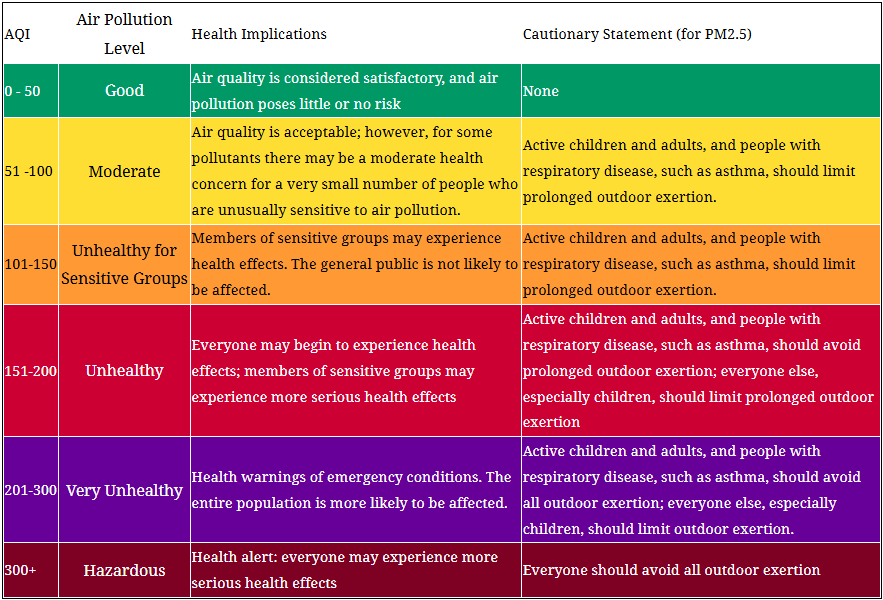

In [ ]:
def tentukan_kategori_aqi(pm25):
    if pm25 <= 50:
        return 'Good (Baik)'
    elif pm25 <= 100:
        return 'Moderate (Sedang)'
    elif pm25 <= 150:
        return 'Unhealthy for Sensitive Groups (Tidak Sehat bagi Kelompok Sensitif)'
    elif pm25 <= 200:
        return 'Unhealthy (Tidak Sehat)'
    elif pm25 <= 300:
        return 'Very Unhealthy (Sangat Tidak Sehat)'
    else:
        return 'Hazardous (Berbahaya)'

df_clean['kategori_udara'] = df_clean['pm25'].apply(tentukan_kategori_aqi)

# Cek distribusi kategori udara untuk melihat seberapa sering Pontianak berada di level tertentu
print("Distribusi Kategori Kualitas Udara:")
print(df_clean['kategori_udara'].value_counts())

Distribusi Kategori Kualitas Udara:
kategori_udara
Moderate (Sedang)                                                      743
Good (Baik)                                                            737
Unhealthy for Sensitive Groups (Tidak Sehat bagi Kelompok Sensitif)    158
Unhealthy (Tidak Sehat)                                                 44
Very Unhealthy (Sangat Tidak Sehat)                                     24
Hazardous (Berbahaya)                                                   21
Name: count, dtype: int64


In [ ]:
print(df_clean.head())

        date  Bawang Merah  Bawang Merah Ukuran Sedang  Bawang Putih  \
0 2022-01-03       29400.0                     29400.0       27500.0   
1 2022-01-04       29400.0                     29400.0       27750.0   
2 2022-01-05       30650.0                     30650.0       27750.0   
3 2022-01-06       30650.0                     30650.0       27500.0   
4 2022-01-07       30900.0                     30900.0       27500.0   

   Bawang Putih Ukuran Sedang    Beras  Beras Kualitas Medium I  \
0                     27500.0  13750.0                  13900.0   
1                     27750.0  13750.0                  13900.0   
2                     27750.0  13750.0                  13900.0   
3                     27500.0  13750.0                  13900.0   
4                     27500.0  13750.0                  13900.0   

   Beras Kualitas Medium II  Beras Kualitas Super I  Beras Kualitas Super II  \
0                   12900.0                 14050.0                  14050.0   
1   

# EDA

=== STATISTIK DESKRIPTIF SELURUH KOMODITAS & PM2.5 ===
          pm25  Bawang Merah  Bawang Merah Ukuran Sedang  Bawang Putih  \
count  1727.00       1727.00                     1727.00       1727.00   
mean     68.39      39272.99                    39269.48      33317.37   
std      51.51       9790.62                     9792.61       6250.88   
min       6.00      24150.00                    24150.00      21400.00   
25%      40.00      32700.00                    32650.00      28400.00   
50%      55.00      37400.00                    37400.00      34750.00   
75%      77.72      44150.00                    44150.00      37500.00   
max     513.00      82500.00                    82500.00      52500.00   

       Bawang Putih Ukuran Sedang     Beras  Beras Kualitas Medium I  \
count                     1727.00   1727.00                  1727.00   
mean                     33314.59  16294.93                 16588.33   
std                       6249.06   1380.56                  1

/tmp/ipykernel_1463/742350391.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


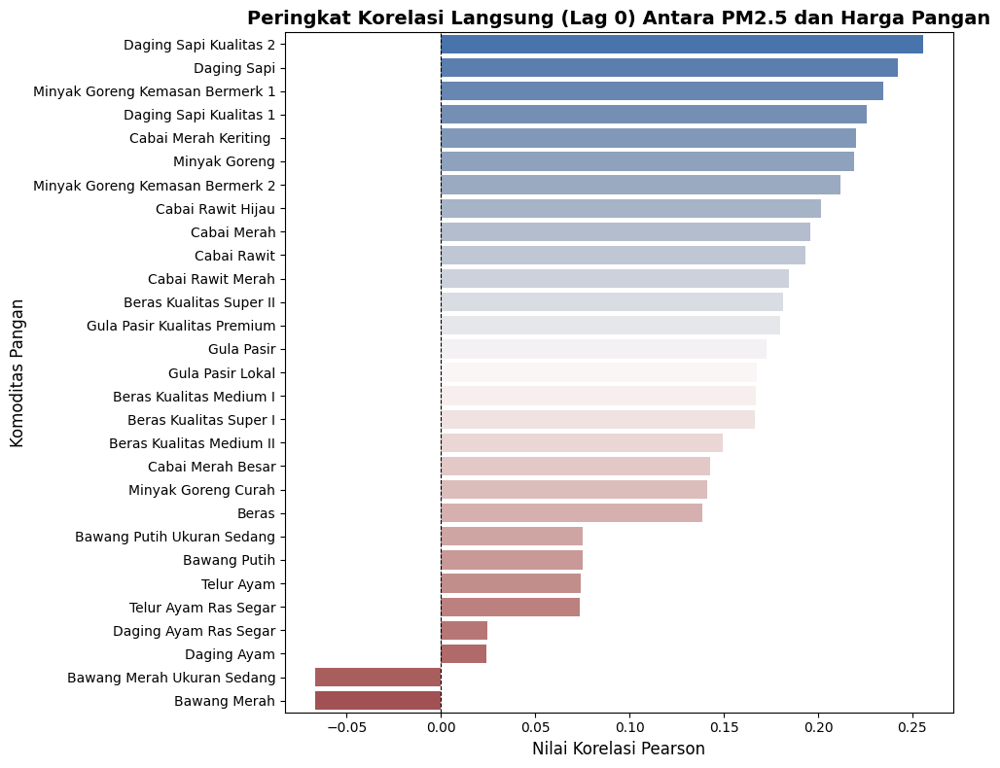

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

cols_harga_all = [col for col in df_clean.columns if col not in ['date', 'pm25', 'kategori_udara']]

# 1. Statistik Deskriptif untuk SELURUH Komoditas dan PM2.5
print("=== STATISTIK DESKRIPTIF SELURUH KOMODITAS & PM2.5 ===")
kolom_statistik = ['pm25'] + cols_harga_all
print(df_clean[kolom_statistik].describe().round(2))

# 2. Distribusi Frekuensi Kategori Kualitas Udara
print("\n=== DISTRIBUSI KATEGORI KUALITAS UDARA ===")
freq_kategori = df_clean['kategori_udara'].value_counts()
persen_kategori = (df_clean['kategori_udara'].value_counts(normalize=True) * 100).round(2)

df_distribusi_udara = pd.DataFrame({
    'Jumlah Hari': freq_kategori,
    'Persentase (%)': persen_kategori
})
print(df_distribusi_udara)

# 3. Matriks Korelasi (Menyeluruh antara PM2.5 dengan Semua Komoditas pada Lag 0)
print("\n=== KORELASI AWAL (LAG 0) ANTARA PM2.5 DAN SEMUA KOMODITAS ===")
korelasi_semua = df_clean[cols_harga_all].corrwith(df_clean['pm25']).reset_index()
korelasi_semua.columns = ['Komoditas', 'Korelasi_dengan_PM25']
korelasi_semua = korelasi_semua.sort_values(by='Korelasi_dengan_PM25', ascending=False)
print(korelasi_semua.to_string(index=False))

# kita buat Visualisasi Heatmap korelasi atau bar chart peringkat korelasi komoditas tertinggi.
plt.figure(figsize=(10, 8))
sns.barplot(
    data=korelasi_semua,
    x='Korelasi_dengan_PM25',
    y='Komoditas',
    palette='vlag'
)
plt.title('Peringkat Korelasi Langsung (Lag 0) Antara PM2.5 dan Harga Pangan', fontsize=14, fontweight='bold')
plt.xlabel('Nilai Korelasi Pearson', fontsize=12)
plt.ylabel('Komoditas Pangan', fontsize=12)
plt.axvline(0, color='black', linestyle='--', linewidth=0.8)
plt.tight_layout()
plt.show()

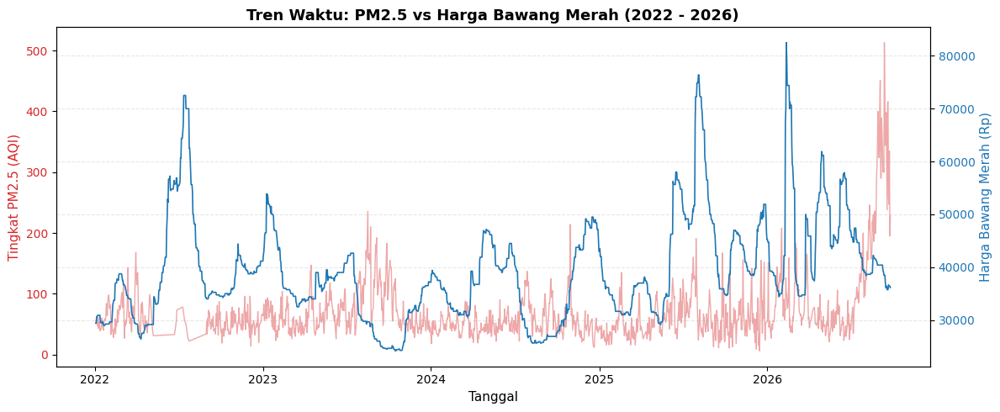

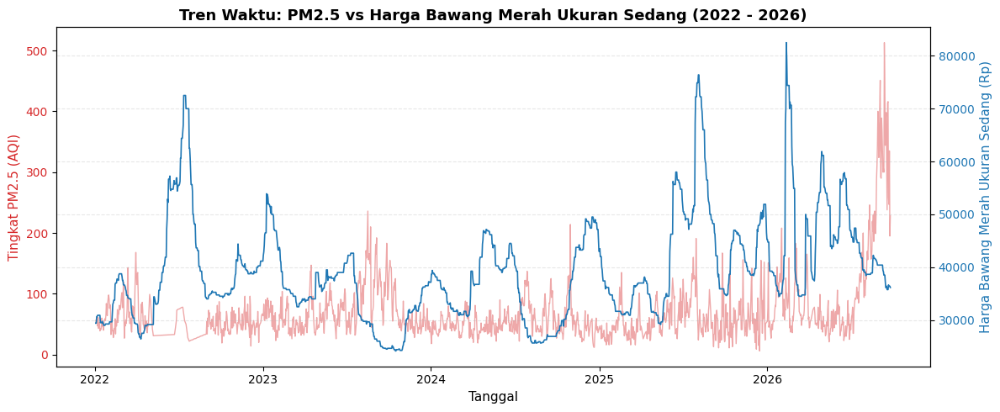

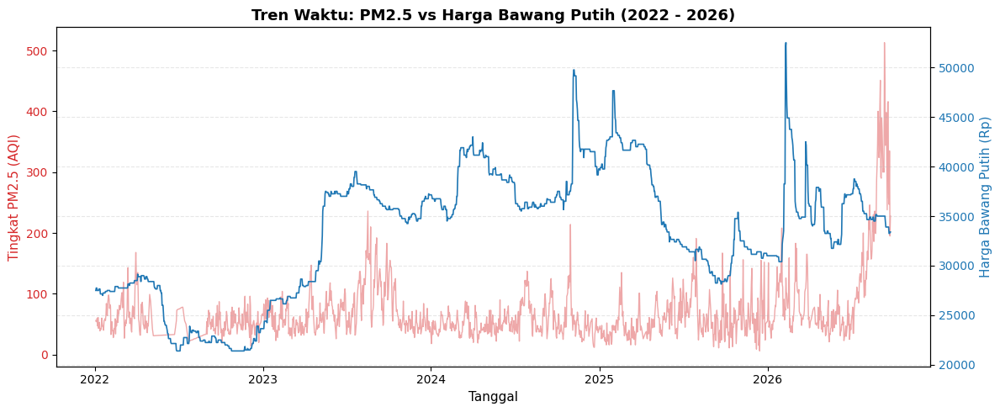

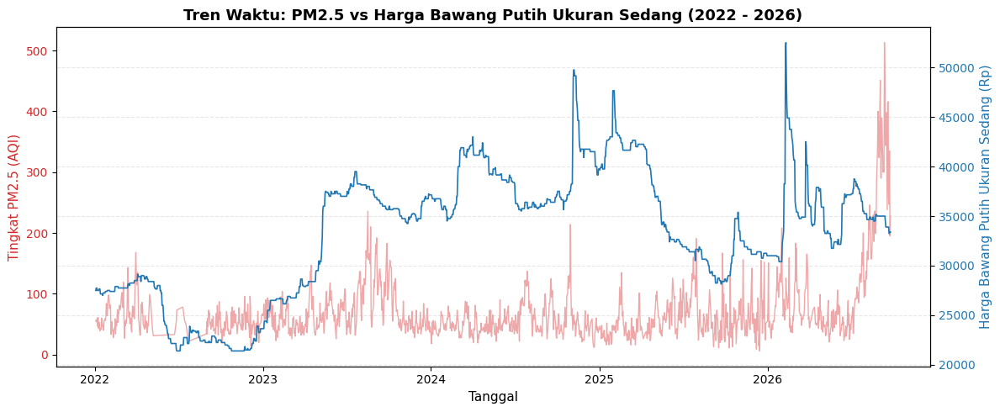

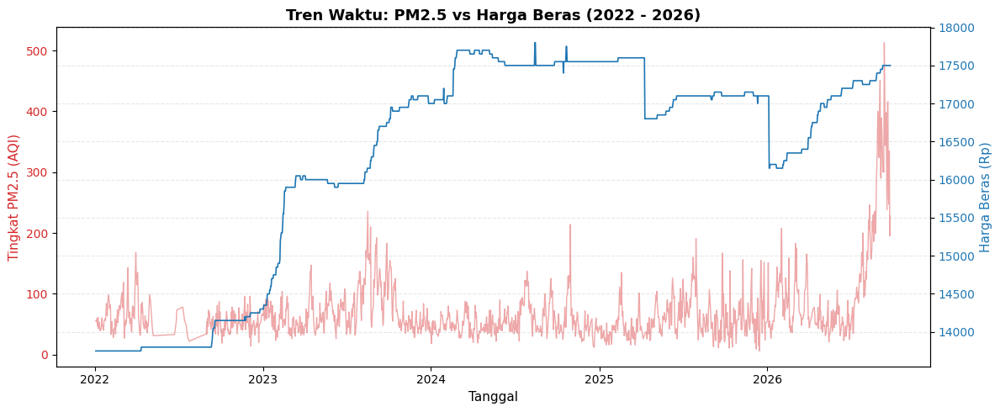

...

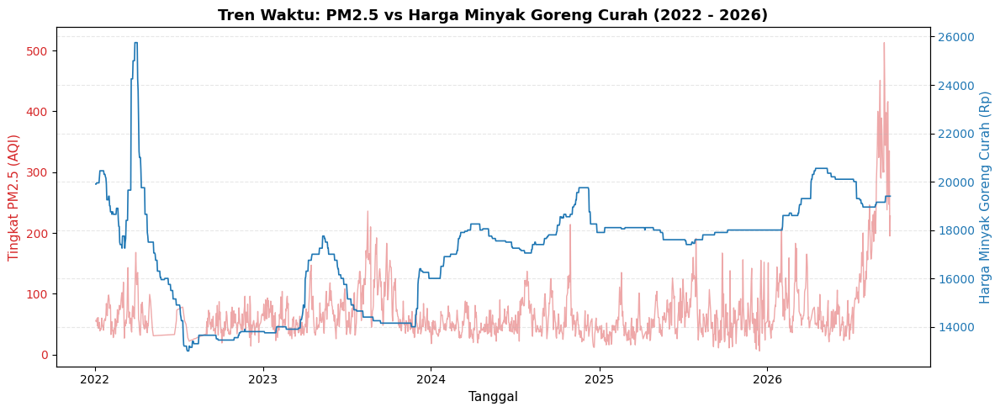

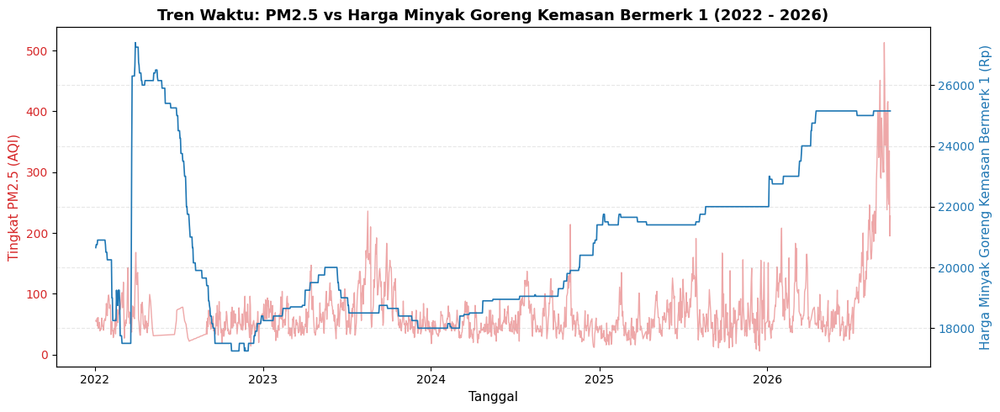

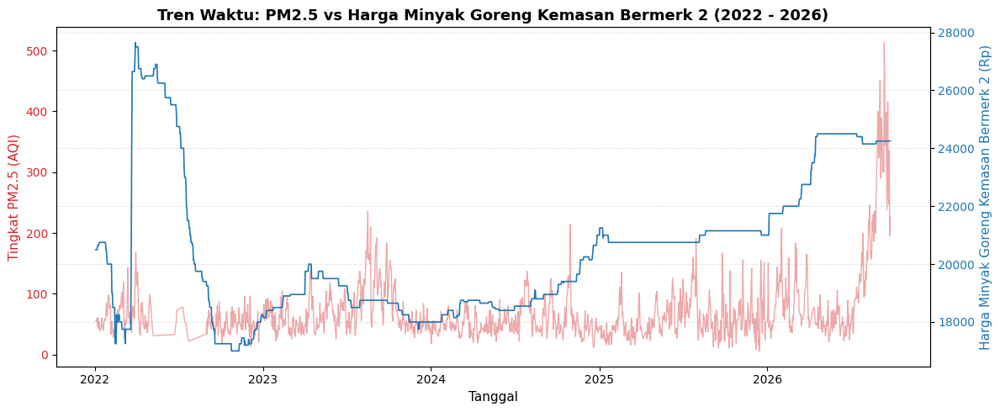

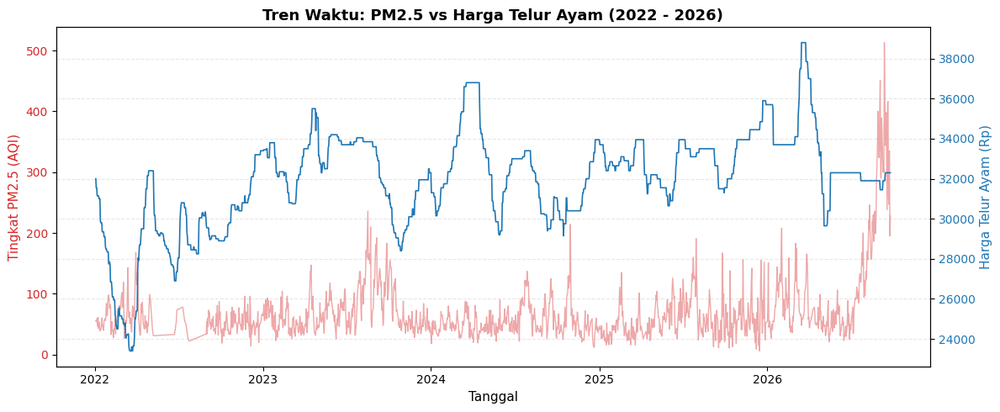

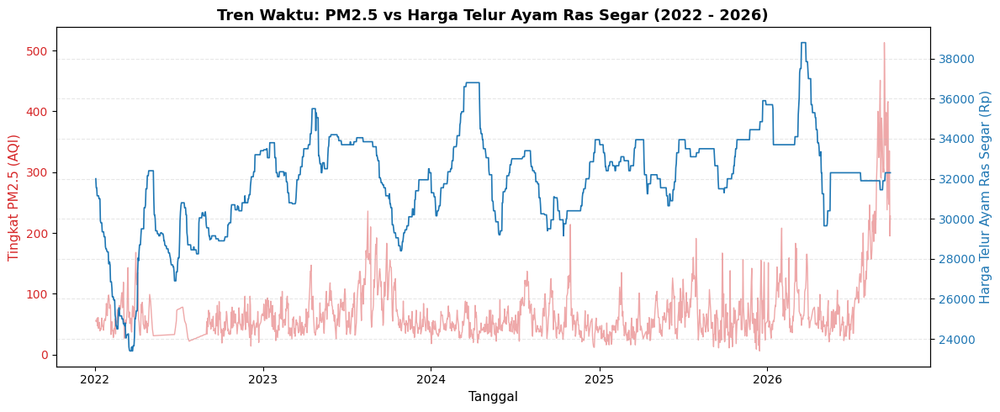

In [ ]:
import matplotlib.pyplot as plt
import os

simpan_ke_folder = False

if simpan_ke_folder:
    os.makedirs('grafik_dual_axis', exist_ok=True)

# Loop otomatis untuk setiap komoditas
for komoditas in cols_harga_all:
    fig, ax1 = plt.subplots(figsize=(12, 5))

    # Sumbu Y pertama untuk PM2.5 (Warna Merah)
    color = 'tab:red'
    ax1.set_xlabel('Tanggal', fontsize=11)
    ax1.set_ylabel('Tingkat PM2.5 (AQI)', color=color, fontsize=11)
    ax1.plot(df_clean['date'], df_clean['pm25'], color=color, alpha=0.4, linewidth=1, label='PM2.5')
    ax1.tick_params(axis='y', labelcolor=color)

    # Sumbu Y kedua untuk Harga Komoditas (Warna Biru)
    ax2 = ax1.twinx()
    color = 'tab:blue'
    ax2.set_ylabel(f'Harga {komoditas} (Rp)', color=color, fontsize=11)
    ax2.plot(df_clean['date'], df_clean[komoditas], color=color, linewidth=1.2, label=komoditas)
    ax2.tick_params(axis='y', labelcolor=color)

    plt.title(f'Tren Waktu: PM2.5 vs Harga {komoditas} (2022 - 2026)', fontsize=13, fontweight='bold')
    fig.tight_layout()
    plt.grid(True, linestyle='--', alpha=0.3)

    if simpan_ke_folder:
        nama_file = komoditas.replace(' ', '_').replace('/', '_')
        plt.savefig(f'grafik_dual_axis/{nama_file}.png', dpi=300)
        plt.close()
    else:
        plt.show()

if simpan_ke_folder:
    print("Semua grafik berhasil disimpan ke dalam folder 'grafik_dual_axis'!")

In [ ]:
import pandas as pd

# List untuk menampung data puncak lonjakan harga
puncak_lonjakan = []

for komoditas in cols_harga_all:
    # Cari 3 tanggal dengan harga tertinggi (puncak) untuk setiap komoditas
    top_peaks = df_clean.nlargest(3, komoditas)[['date', komoditas, 'pm25', 'kategori_udara']]

    for _, row in top_peaks.iterrows():
        puncak_lonjakan.append({
            'Komoditas': komoditas,
            'Tanggal Puncak': row['date'].strftime('%Y-%m-%d'),
            'Bulan/Tahun': row['date'].strftime('%B %Y'),
            'Harga (Rp)': row[komoditas],
            'PM2.5': row['pm25'],
            'Kategori Udara': row['kategori_udara']
        })

# Konversi ke DataFrame
df_puncak = pd.DataFrame(puncak_lonjakan)

# Tampilkan ringkasan tanggal puncak harga untuk beberapa komoditas utama
print("=== TANGGAL PUNCAK HARGA TERTINGGI TIAP KOMODITAS ===")
print(df_puncak.head(15).to_string(index=False))

# Melihat bulan apa saja yang paling sering muncul sebagai waktu terjadinya puncak harga
print("\n=== DISTRIBUSI BULAN TERJADINYA PUNCAK HARGA (SELURUH KOMODITAS) ===")
print(df_puncak['Bulan/Tahun'].value_counts().head(10))

=== TANGGAL PUNCAK HARGA TERTINGGI TIAP KOMODITAS ===
                 Komoditas Tanggal Puncak   Bulan/Tahun  Harga (Rp)  PM2.5                                                      Kategori Udara
              Bawang Merah     2026-02-11 February 2026     82500.0  102.0 Unhealthy for Sensitive Groups (Tidak Sehat bagi Kelompok Sensitif)
              Bawang Merah     2026-02-12 February 2026     79400.0  101.0 Unhealthy for Sensitive Groups (Tidak Sehat bagi Kelompok Sensitif)
              Bawang Merah     2025-08-04   August 2025     76400.0   24.0                                                         Good (Baik)
Bawang Merah Ukuran Sedang     2026-02-11 February 2026     82500.0  102.0 Unhealthy for Sensitive Groups (Tidak Sehat bagi Kelompok Sensitif)
Bawang Merah Ukuran Sedang     2026-02-12 February 2026     79400.0  101.0 Unhealthy for Sensitive Groups (Tidak Sehat bagi Kelompok Sensitif)
Bawang Merah Ukuran Sedang     2025-08-04   August 2025     76400.0   24.0              

In [ ]:
import pandas as pd

# 1. Filter data khusus untuk tahun 2026
df_2026 = df_clean[df_clean['date'].dt.year == 2026].copy()

puncak_lonjakan_2026 = []

for komoditas in cols_harga_all:
    if len(df_2026) > 0:
        # Cari 2 tanggal dengan harga tertinggi khusus di dalam rentang tahun 2026
        top_peaks = df_2026.nlargest(2, komoditas)[['date', komoditas, 'pm25', 'kategori_udara']]

        for _, row in top_peaks.iterrows():
            puncak_lonjakan_2026.append({
                'Komoditas': komoditas,
                'Tanggal Puncak': row['date'].strftime('%Y-%m-%d'),
                'Bulan': row['date'].strftime('%B'),
                'Harga (Rp)': row[komoditas],
                'PM2.5': row['pm25'],
                'Kategori Udara': row['kategori_udara']
            })

# Konversi ke DataFrame
df_puncak_2026 = pd.DataFrame(puncak_lonjakan_2026)

# Tampilkan hasil puncak harga tahun 2026
print("=== TANGGAL PUNCAK HARGA TERTINGGI KHUSUS TAHUN 2026 ===")
print(df_puncak_2026.head(20).to_string(index=False))

# Melihat bulan apa saja yang paling sering memegang rekor harga tertinggi di 2026
print("\n=== DISTRIBUSI BULAN PUNCAK HARGA DI TAHUN 2026 ===")
print(df_puncak_2026['Bulan'].value_counts())

=== TANGGAL PUNCAK HARGA TERTINGGI KHUSUS TAHUN 2026 ===
                 Komoditas Tanggal Puncak     Bulan  Harga (Rp)  PM2.5                                                      Kategori Udara
              Bawang Merah     2026-02-11  February     82500.0  102.0 Unhealthy for Sensitive Groups (Tidak Sehat bagi Kelompok Sensitif)
              Bawang Merah     2026-02-12  February     79400.0  101.0 Unhealthy for Sensitive Groups (Tidak Sehat bagi Kelompok Sensitif)
Bawang Merah Ukuran Sedang     2026-02-11  February     82500.0  102.0 Unhealthy for Sensitive Groups (Tidak Sehat bagi Kelompok Sensitif)
Bawang Merah Ukuran Sedang     2026-02-12  February     79400.0  101.0 Unhealthy for Sensitive Groups (Tidak Sehat bagi Kelompok Sensitif)
              Bawang Putih     2026-02-10  February     52500.0  126.0 Unhealthy for Sensitive Groups (Tidak Sehat bagi Kelompok Sensitif)
              Bawang Putih     2026-02-09  February     51900.0   73.0                                       

# CHECKIN

In [ ]:
import pandas as pd
import numpy as np

# 1. Tentukan rentang max_lag (misalnya dari hari ke-0 sampai ke-14)
max_lag = 14
hasil_time_lag = []

# Loop untuk setiap komoditas harga
for komoditas in cols_harga_all:
    korelasi_per_lag = {}

    for lag in range(max_lag + 1):
        # Shift negatif: membandingkan PM2.5 hari ini dengan harga pangan 'lag' hari ke depan
        harga_shifted = df_clean[komoditas].shift(-lag)

        # Hitung korelasi Pearson
        corr = df_clean['pm25'].corr(harga_shifted)
        korelasi_per_lag[lag] = corr

    # Temukan lag dengan nilai korelasi tertinggi (paling kuat pengaruhnya)
    lag_optimal = max(korelasi_per_lag, key=korelasi_per_lag.get)
    korelasi_puncak = korelasi_per_lag[lag_optimal]
    korelasi_lag_0 = korelasi_per_lag[0]

    hasil_time_lag.append({
        'Komoditas': komoditas,
        'Lag Optimal (Hari)': lag_optimal,
        'Korelasi Puncak': korelasi_puncak,
        'Korelasi Hari ke-0': korelasi_lag_0,
        'Selisih Peningkatan Korelasi': korelasi_puncak - korelasi_lag_0
    })

# 2. Konversi ke DataFrame agar rapi dan urutkan berdasarkan korelasi puncak tertinggi
df_hasil_lag = pd.DataFrame(hasil_time_lag)
df_hasil_lag = df_hasil_lag.sort_values(by='Korelasi Puncak', ascending=False).reset_index(drop=True)

print("=== HASIL ANALISIS TIME-LAG KORELASI PM2.5 VS HARGA PANGAN (0-14 HARI) ===")
print(df_hasil_lag.to_string(index=False))

=== HASIL ANALISIS TIME-LAG KORELASI PM2.5 VS HARGA PANGAN (0-14 HARI) ===
                      Komoditas  Lag Optimal (Hari)  Korelasi Puncak  Korelasi Hari ke-0  Selisih Peningkatan Korelasi
          Cabai Merah Keriting                   14         0.288883            0.219898                      0.068985
                    Cabai Merah                  12         0.257767            0.195855                      0.061912
         Daging Sapi Kualitas 2                   0         0.255626            0.255626                      0.000000
                    Daging Sapi                   0         0.242084            0.242084                      0.000000
              Cabai Rawit Hijau                  13         0.242005            0.201807                      0.040197
Minyak Goreng Kemasan Bermerk 1                   0         0.234518            0.234518                      0.000000
                    Cabai Rawit                  13         0.233181            0.193338    

In [ ]:
import pandas as pd

# 1. Filter data khusus tahun 2026
df_2026 = df_clean[df_clean['date'].dt.year == 2026].copy()

# 2. Definisikan periode waktu
# Periode Sebelum Karhutla: Januari s.d. Juli 2026
# Periode Musim Karhutla: Agustus s.d. September 2026
sebelum_karhutla = df_2026[df_2026['date'].dt.month.isin([1, 2, 3, 4, 5, 6, 7])]
musim_karhutla = df_2026[df_2026['date'].dt.month.isin([8, 9])]

# 3. Hitung rata-rata harga untuk seluruh komoditas di kedua periode
mean_sebelum = sebelum_karhutla[cols_harga_all].mean()
mean_karhutla = musim_karhutla[cols_harga_all].mean()

# 4. Hitung persentase kenaikan (%)
persen_kenaikan = ((mean_karhutla - mean_sebelum) / mean_sebelum) * 100

# 5. Buat DataFrame ringkasan yang rapi
df_perbandingan_2026 = pd.DataFrame({
    'Rata2 Sebelum (Jan-Jul)': mean_sebelum,
    'Rata2 Karhutla (Agu-Sep)': mean_karhutla,
    'Kenaikan (%)': persen_kenaikan
}).sort_values(by='Kenaikan (%)', ascending=False)

print("=== PERBANDINGAN HARGA PANGAN SEBELUM VS MUSIM KARHUTLA 2026 ===")
print(df_perbandingan_2026.round(2).to_string())

=== PERBANDINGAN HARGA PANGAN SEBELUM VS MUSIM KARHUTLA 2026 ===
                                 Rata2 Sebelum (Jan-Jul)  Rata2 Karhutla (Agu-Sep)  Kenaikan (%)
Cabai Rawit Hijau                               66985.38                  90068.75         34.46
Cabai Rawit                                     73248.11                  97149.11         32.63
Cabai Rawit Merah                               79508.49                 104223.21         31.08
Cabai Merah Keriting                            65347.17                  83199.11         27.32
Cabai Merah                                     66579.48                  80666.96         21.16
Cabai Merah Besar                               67806.60                  78128.57         15.22
Beras Kualitas Medium II                        16419.10                  17251.79          5.07
Beras Kualitas Super II                         17658.96                  18378.57          4.08
Beras                                           16750.47      

=== HASIL DEKOMPOSISI & KORELASI RESIDUAL UNTUK CABAI RAWIT MERAH ===
Korelasi antara Residual Harga (setelah dikurangi Tren & Musiman) dengan PM2.5: -0.1261


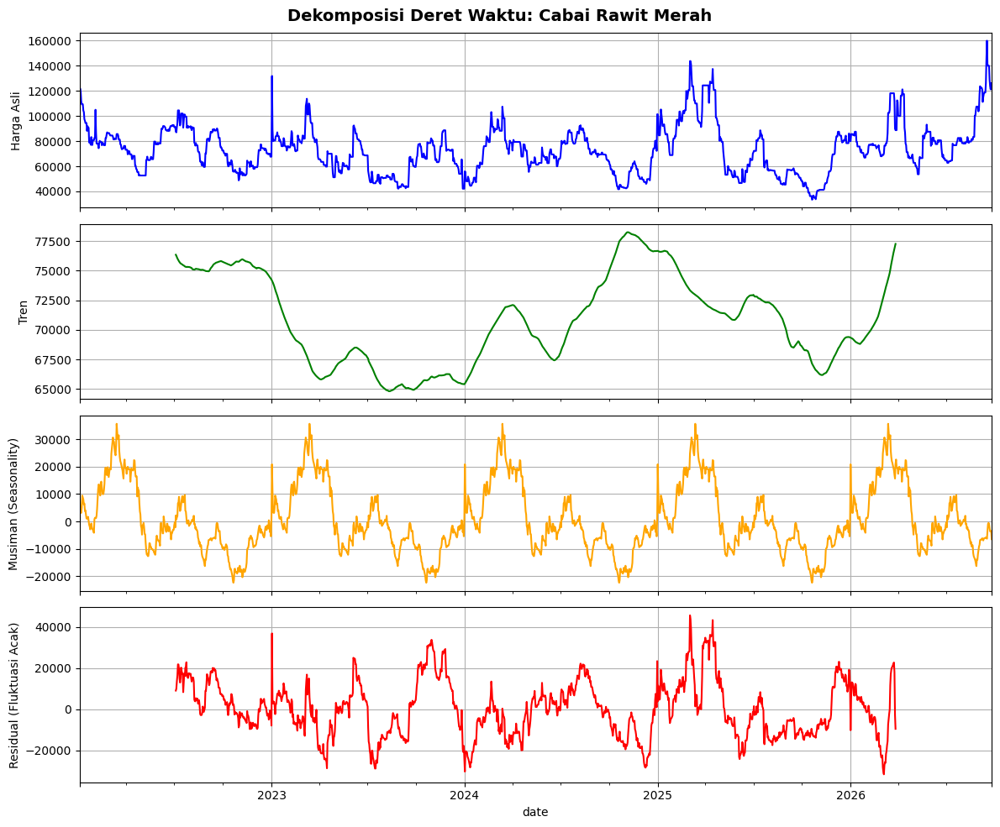

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# 1. Pilih salah satu komoditas target untuk diuji
target_komoditas = 'Cabai Rawit Merah'

# Pastikan data diurutkan berdasarkan tanggal secara kronologis
df_clean = df_clean.sort_values('date').reset_index(drop=True)

# Set kolom 'date' sebagai index sementara agar statsmodels bisa membaca frekuensi harian ('D')
df_ts = df_clean.set_index('date')

# 2. Jalankan Dekomposisi (Additive Model)
# period=365 karena polanya berulang secara tahunan (365 hari)
decomposition = seasonal_decompose(df_ts[target_komoditas], model='additive', period=365)

# 3. Ekstrak komponen ke dalam dataframe baru
df_decomp = pd.DataFrame({
    'trend': decomposition.trend,
    'seasonality': decomposition.seasonal,
    'residual': decomposition.resid,
    'pm25': df_ts['pm25']
}).dropna() # Buang baris NaN hasil kalkulasi awal/akhir dekomposisi

# 4. Hitung Korelasi antara Komponen Residual Harga dengan PM2.5
korelasi_residual = df_decomp['residual'].corr(df_decomp['pm25'])

print(f"=== HASIL DEKOMPOSISI & KORELASI RESIDUAL UNTUK {target_komoditas.upper()} ===")
print(f"Korelasi antara Residual Harga (setelah dikurangi Tren & Musiman) dengan PM2.5: {korelasi_residual:.4f}")

# 5. Visualisasi Hasil Dekomposisi
fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(12, 10), sharex=True)

decomposition.observed.plot(ax=ax1, color='blue')
ax1.set_ylabel('Harga Asli')
ax1.grid(True)

decomposition.trend.plot(ax=ax2, color='green')
ax2.set_ylabel('Tren')
ax2.grid(True)

decomposition.seasonal.plot(ax=ax3, color='orange')
ax3.set_ylabel('Musiman (Seasonality)')
ax3.grid(True)

decomposition.resid.plot(ax=ax4, color='red')
ax4.set_ylabel('Residual (Fluktuasi Acak)')
ax4.grid(True)

plt.suptitle(f'Dekomposisi Deret Waktu: {target_komoditas}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
from statsmodels.tsa.seasonal import seasonal_decompose

# Pastikan data terurut kronologis dan berindeks waktu
df_clean = df_clean.sort_values('date').reset_index(drop=True)
df_ts = df_clean.set_index('date')

hasil_korelasi_residual = []

for komoditas in cols_harga_all:
    try:
        # Lakukan dekomposisi aditif dengan period 365 hari
        decomposition = seasonal_decompose(df_ts[komoditas], model='additive', period=365)

        # Gabungkan komponen residual harga dan pm25, lalu buang nilai NaN
        temp_df = pd.DataFrame({
            'residual_harga': decomposition.resid,
            'pm25': df_ts['pm25']
        }).dropna()

        # Hitung korelasi Pearson antara Residual Harga dan PM2.5
        corr = temp_df['residual_harga'].corr(temp_df['pm25'])

        hasil_korelasi_residual.append({
            'Komoditas': komoditas,
            'Korelasi Residual (Harga vs PM2.5)': corr
        })
    except Exception as e:
        print(f"Gagal memproses {komoditas}: {e}")

# Konversi ke DataFrame yang rapi dan urutkan dari korelasi tertinggi
df_res_corr = pd.DataFrame(hasil_korelasi_residual)
df_res_corr = df_res_corr.sort_values(by='Korelasi Residual (Harga vs PM2.5)', ascending=False).reset_index(drop=True)

print("=== KORELASI BERSIH: RESIDUAL HARGA VS PM2.5 ===")
print(df_res_corr.to_string(index=False))

=== KORELASI BERSIH: RESIDUAL HARGA VS PM2.5 ===
                      Komoditas  Korelasi Residual (Harga vs PM2.5)
                     Telur Ayam                            0.165590
           Telur Ayam Ras Segar                            0.164694
Minyak Goreng Kemasan Bermerk 2                            0.068269
                   Bawang Putih                            0.066703
     Bawang Putih Ukuran Sedang                            0.066016
                  Minyak Goreng                            0.058675
Minyak Goreng Kemasan Bermerk 1                            0.056812
          Daging Ayam Ras Segar                            0.035428
                    Daging Ayam                            0.034835
            Minyak Goreng Curah                            0.019603
         Beras Kualitas Super I                           -0.055591
         Daging Sapi Kualitas 1                           -0.088284
              Cabai Merah Besar                           -0.106792

In [ ]:
import pandas as pd

# 1. Buat kolom tahun dan kelompok status AQI
df_clean['tahun'] = df_clean['date'].dt.year
df_clean['status_aqi'] = df_clean['pm25'].apply(lambda x: 'AQI Tinggi (>100)' if x > 100 else 'AQI Normal (<=100)')

hasil_tahunan = []

# 2. Lakukan perulangan untuk setiap tahun (2022 s.d. 2026)
for tahun in sorted(df_clean['tahun'].unique()):
    df_tahunan = df_clean[df_clean['tahun'] == tahun]

    # Hitung rata-rata harga saat AQI Normal dan AQI Tinggi
    mean_normal = df_tahunan[df_tahunan['status_aqi'] == 'AQI Normal (<=100)'][cols_harga_all].mean()
    mean_tinggi = df_tahunan[df_tahunan['status_aqi'] == 'AQI Tinggi (>100)'][cols_harga_all].mean()

    # Hitung persentase kenaikan
    pct_change = ((mean_tinggi - mean_normal) / mean_normal) * 100

    for komoditas in cols_harga_all:
        hasil_tahunan.append({
            'Tahun': tahun,
            'Komoditas': komoditas,
            'Rata2 Normal (Rp)': mean_normal[komoditas],
            'Rata2 Tinggi (Rp)': mean_tinggi[komoditas],
            'Kenaikan (%)': pct_change[komoditas]
        })

df_perbandingan_tahun = pd.DataFrame(hasil_tahunan)

# 3. Tampilkan contoh hasil untuk tahun tertentu (misal tahun 2023)
tahun_pilih = 2026
print(f"=== PERBANDINGAN HARGA SAAT AQI TINGGI VS NORMAL TAHUN {tahun_pilih} ===")
print(df_perbandingan_tahun[df_perbandingan_tahun['Tahun'] == tahun_pilih].sort_values(by='Kenaikan (%)', ascending=False).head(10).to_string(index=False))

# Jika ingin melihat semua tahun dan menyimpannya ke Excel/CSV:
# df_perbandingan_tahun.to_excel('perbandingan_harga_aqi_tahunan.xlsx', index=False)

=== PERBANDINGAN HARGA SAAT AQI TINGGI VS NORMAL TAHUN 2026 ===
 Tahun                Komoditas  Rata2 Normal (Rp)  Rata2 Tinggi (Rp)  Kenaikan (%)
  2026        Cabai Rawit Hijau       67065.740741       79057.547170     17.880674
  2026              Cabai Rawit       73433.641975       85591.509434     16.556264
  2026        Cabai Rawit Merah       79797.530864       92123.584906     15.446661
  2026    Cabai Merah Keriting        65503.395062       74539.622642     13.795052
  2026              Cabai Merah       66860.493827       73592.452830     10.068665
  2026        Cabai Merah Besar       68213.580247       72637.735849      6.485740
  2026 Beras Kualitas Medium II       16448.765432       16813.679245      2.218488
  2026  Beras Kualitas Super II       17673.456790       18016.981132      1.943730
  2026   Beras Kualitas Super I       18458.950617       18702.358491      1.318644
  2026                    Beras       16805.246914       16999.056604      1.153269


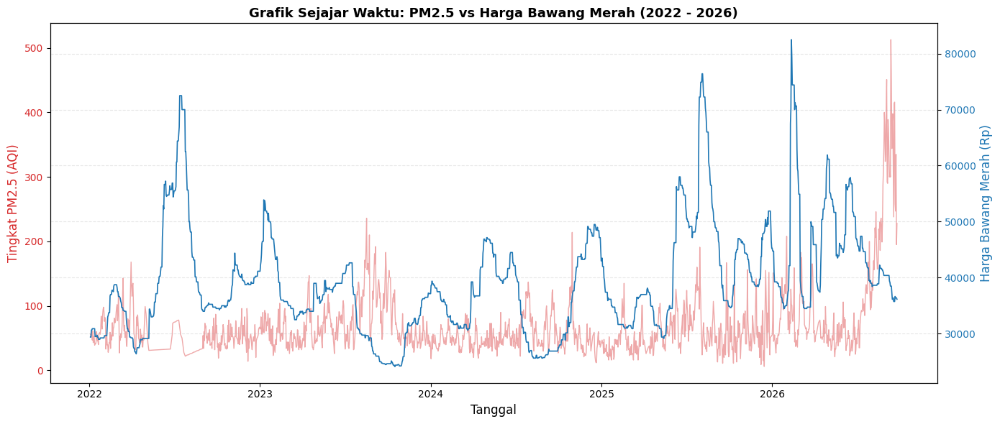

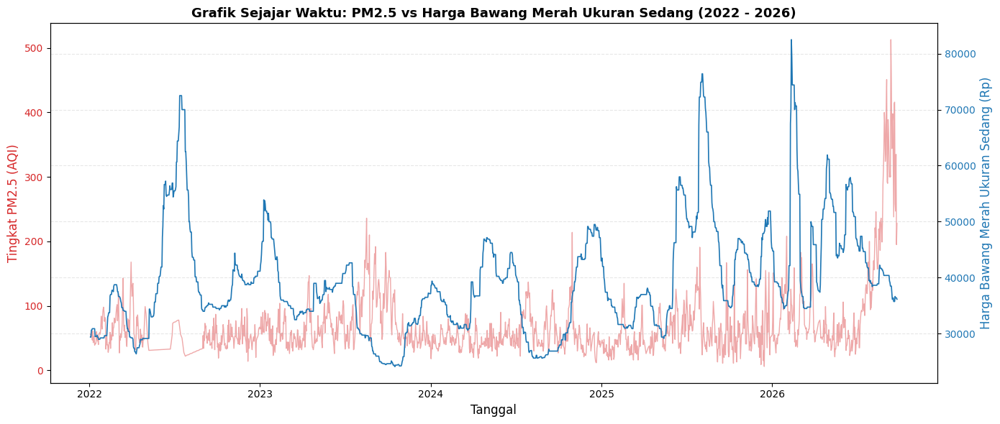

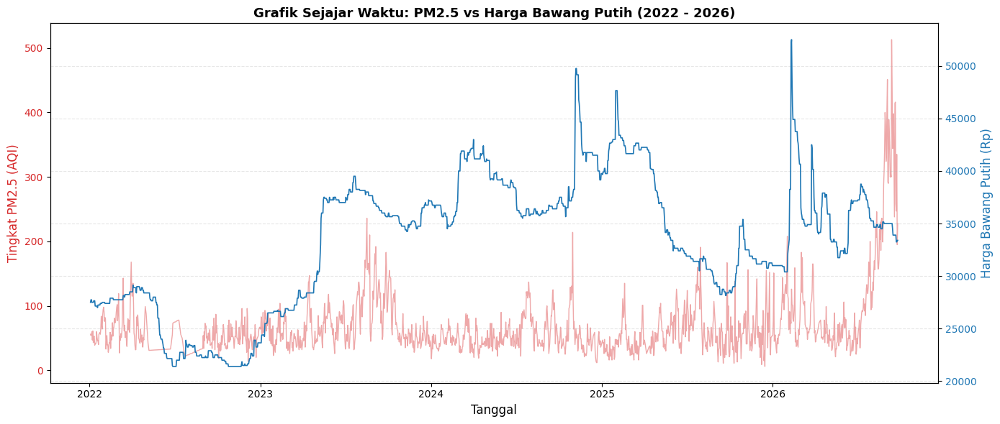

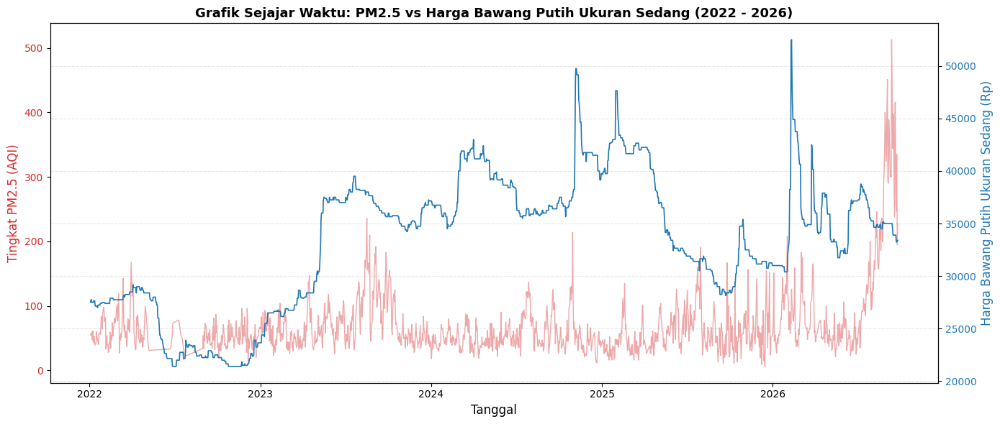

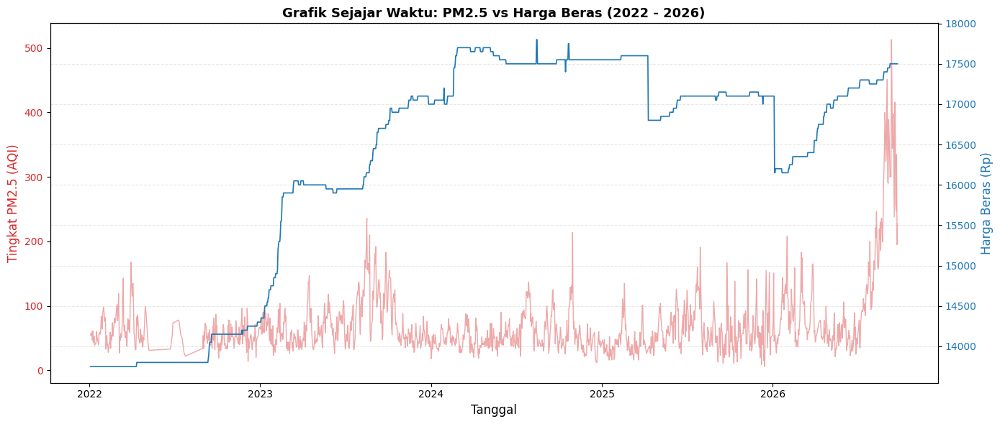

...

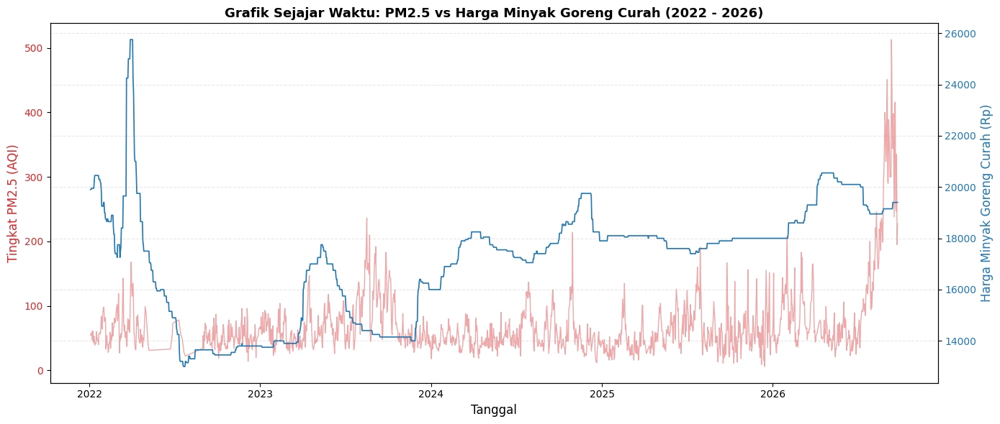

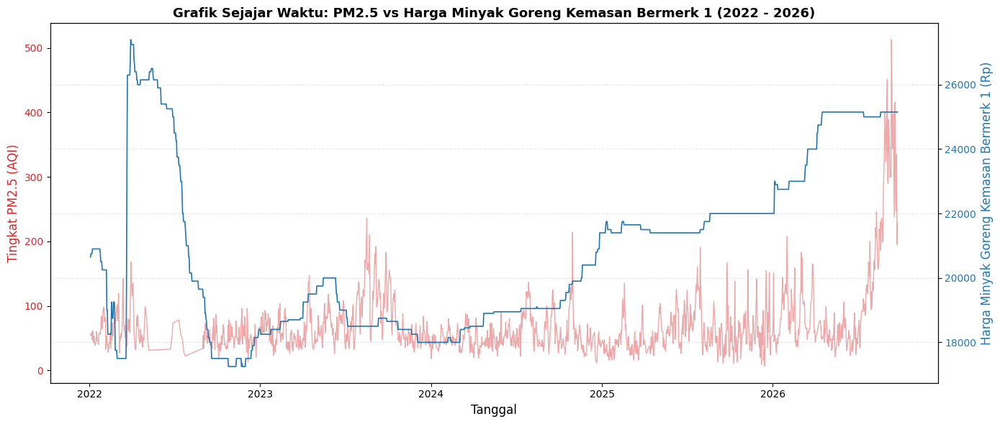

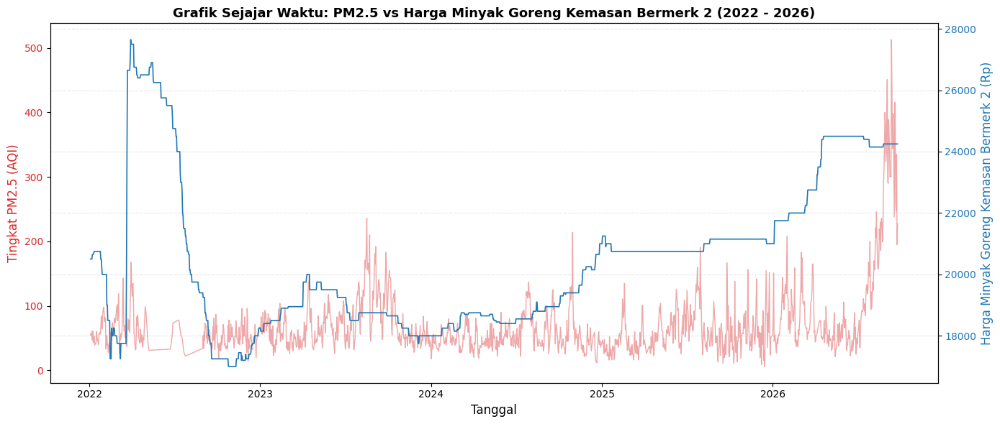

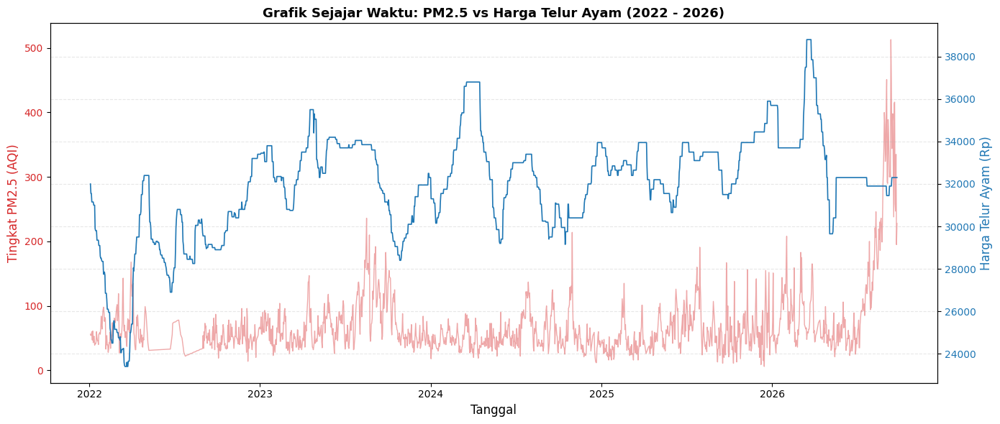

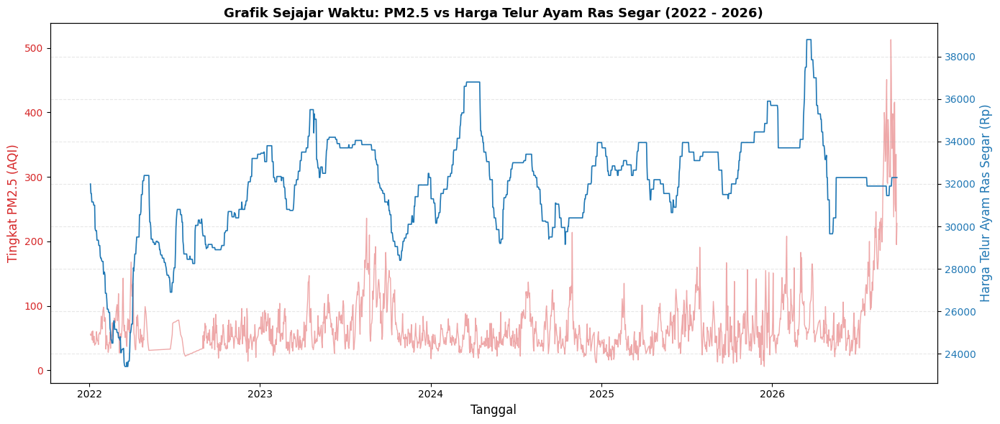

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# Pastikan data terurut kronologis
df_clean = df_clean.sort_values('date').reset_index(drop=True)

# Tentukan apakah ingin menyimpan gambar ke folder (True) atau langsung ditampilkan (False)
simpan_ke_folder = False

if simpan_ke_folder:
    os.makedirs('grafik_dual_axis_waktu', exist_ok=True)

# Loop otomatis untuk setiap komoditas
for komoditas in cols_harga_all:
    fig, ax1 = plt.subplots(figsize=(14, 6))

    # Sumbu Y pertama untuk PM2.5 (Warna Merah)
    color = 'tab:red'
    ax1.set_xlabel('Tanggal', fontsize=12)
    ax1.set_ylabel('Tingkat PM2.5 (AQI)', color=color, fontsize=12)
    ax1.plot(df_clean['date'], df_clean['pm25'], color=color, alpha=0.4, linewidth=1, label='PM2.5')
    ax1.tick_params(axis='y', labelcolor=color)

    # Sumbu Y kedua untuk Harga Komoditas pada waktu yang sama (Warna Biru)
    ax2 = ax1.twinx()
    color = 'tab:blue'
    ax2.set_ylabel(f'Harga {komoditas} (Rp)', color=color, fontsize=12)
    ax2.plot(df_clean['date'], df_clean[komoditas], color=color, linewidth=1.2, label=komoditas)
    ax2.tick_params(axis='y', labelcolor=color)

    plt.title(f'Grafik Sejajar Waktu: PM2.5 vs Harga {komoditas} (2022 - 2026)', fontsize=13, fontweight='bold')
    fig.tight_layout()
    plt.grid(True, linestyle='--', alpha=0.3)

    if simpan_ke_folder:
        nama_file = komoditas.replace(' ', '_').replace('/', '_')
        plt.savefig(f'grafik_dual_axis_waktu/{nama_file}.png', dpi=300)
        plt.close()
    else:
        plt.show()

if simpan_ke_folder:
    print("Semua grafik dual-axis berhasil disimpan ke dalam folder 'grafik_dual_axis_waktu'!")